## Importing Necessary Libraries

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

## Basic Statistics Terms 

In [68]:
# Mean
speed = [99,56,78,25,89,58,78,67,78,89]
mean_speed = np.mean(speed)
mean_speed

71.7

In [69]:
# Median
median_speed = np.median(speed)
median_speed

78.0

In [70]:
# Mode
mode_speed = stats.mode(speed)
mode_speed

ModeResult(mode=78, count=3)

In [71]:
# standard deviation
stdev_speed = np.std(speed)
stdev_speed

20.248703662210083

In [72]:
# variance
var_speed = np.var(speed)
var_speed

410.01000000000005

## Data Distribution and their Representation

In [73]:
# Data Distribution
# Creating a Big data
x = np.random.uniform(0.0,5.0,20)  # It creates an array of 20 elements between 0 and 5 
print(type(x))  # the data will be in uniform distribution
x

<class 'numpy.ndarray'>


array([0.96297907, 4.54241395, 4.90298831, 4.98880728, 0.29522031,
       0.58743686, 3.85920663, 4.00343047, 4.62092787, 1.75324972,
       0.10571164, 1.06919056, 3.36953258, 1.88815663, 0.79439431,
       0.16039127, 1.3329382 , 0.52212839, 3.48582733, 3.99260763])

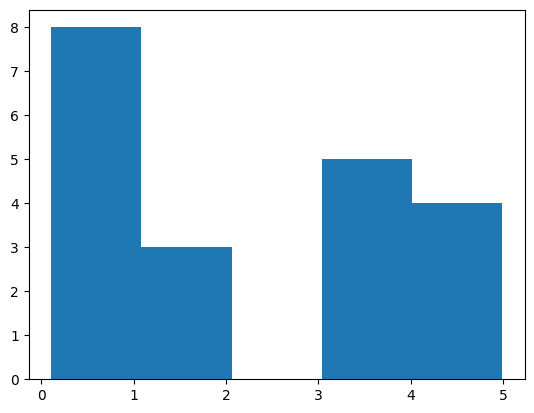

In [74]:
# visuatlizing data
plt.hist(x, 5)
plt.show() # 5 bars

C:\Users\ECS\AppData\Local\Temp\ipykernel_2204\1470859070.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_data, 100)


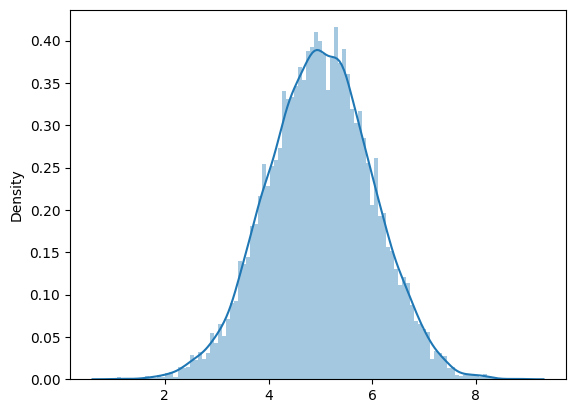

In [117]:
# Normal Distribution
normal_data = np.random.normal(5.0,1.0,10000) # mean = 5, std = 1, values = 50
# print(normal_data)
sns.distplot(normal_data, 100)
plt.show()

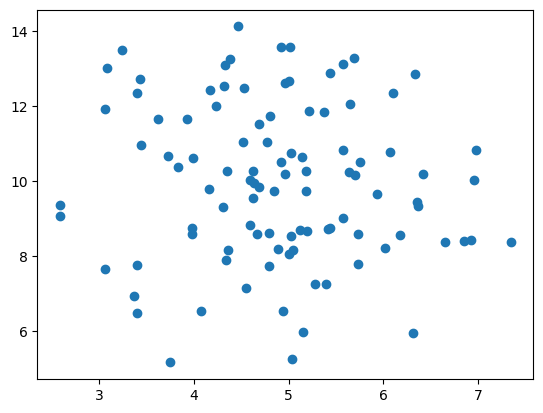

In [76]:
# Scatter Plot
sc_x = np.random.normal(5.0,1.0,100)
sc_y = np.random.normal(10.0,2.0,100)
plt.scatter(sc_x,sc_y)
plt.show()

## Detecting and handling Missing Values

In [77]:
loan_data = pd.read_csv("datasets/loan.csv")
loan_data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [78]:
print(loan_data.isnull().sum(), "\n")
print(f"Total No. of Null Values are: {loan_data.isnull().sum().sum()}\n")
print(loan_data.info())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64 

Total No. of Null Values are: 149

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   

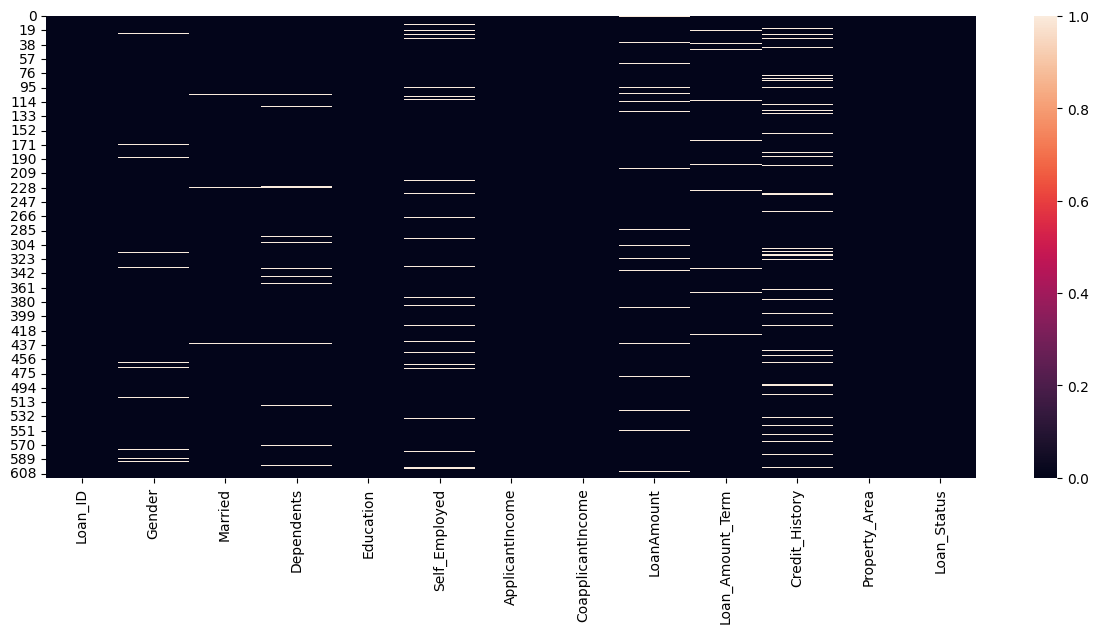

In [79]:
# visualizing the data
plt.figure(figsize = (15,6))
sns.heatmap(loan_data.isnull())
plt.show()

In [80]:
# handling missing values
loan_data.dropna(inplace = True)
loan_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Encoding (ordinal, label)

In [81]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
loan_data["prop_encoded"] = le.fit_transform(loan_data["Property_Area"])
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,prop_encoded
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,2
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,2
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,2
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,2


In [82]:
# Ordinal Encoding using map function
stat_order = {'Y':1, 'N':0}
loan_data["status_encode"] = loan_data["Loan_Status"].map(stat_order)
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,prop_encoded,status_encode
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,2,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,2,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,2,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,2,1


## detecting and fixing outliers

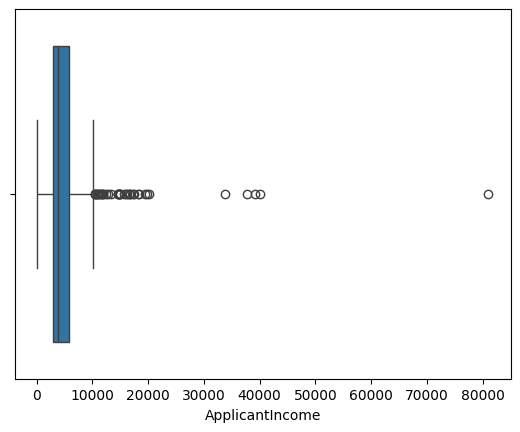

In [83]:
# detecting outliers
sns.boxplot(x = "ApplicantIncome", data = loan_data)
plt.show()

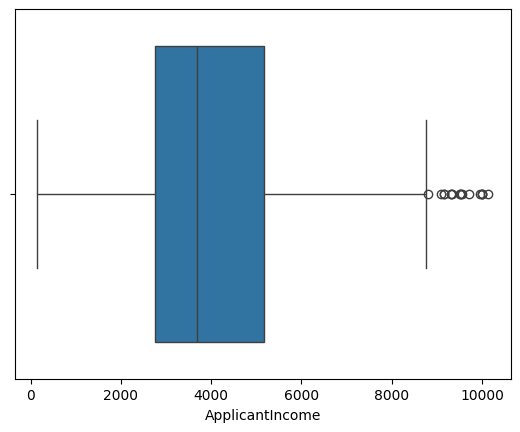

In [84]:
# Removing Outliers using IQR methods
q1 = loan_data['ApplicantIncome'].quantile(0.25)
q3 = loan_data['ApplicantIncome'].quantile(0.75)

# IQR
iqr = q3 - q1

# Min Range
min_range = q1 - (1.5*iqr)
# Max Range
max_range = q3 + (1.5*iqr)

# Eliminating Everything above and below ranges
loan_data = loan_data[loan_data['ApplicantIncome'] <= max_range]
loan_data = loan_data[loan_data['ApplicantIncome'] >= min_range]

sns.boxplot(x = 'ApplicantIncome', data = loan_data)
plt.show()

## Feature scaling

In [85]:
# Generating Random Data
age_col = np.random.randint(18,80,30)
salary_col = np.random.randint(12000, 90000, 30)

fe_data = pd.DataFrame({"age":age_col, "salary": salary_col})

print(fe_data.head(5))
fe_data.to_csv("age_salary.csv", index = False)

   age  salary
0   47   24834
1   44   28461
2   55   81871
3   57   35121
4   44   49281


In [86]:
from sklearn.preprocessing import StandardScaler
fe_data = pd.read_csv("age_salary.csv")
ss = StandardScaler()
ss.fit(fe_data[["salary"]])
fe_data["salary_ss"] = pd.DataFrame(ss.transform(fe_data[['salary']]), columns = ['x'])
fe_data.head(5)

,age,salary,salary_ss
0,47,24834,-0.930214
1,44,28461,-0.761475
2,55,81871,1.723329
3,57,35121,-0.451630
4,44,49281,0.207138


C:\Users\ECS\AppData\Local\Temp\ipykernel_2204\1550279350.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_data["salary"])
C:\Users\ECS\AppData\Local\Temp\ipykernel_2204\1550279350.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_data['salary_ss'])


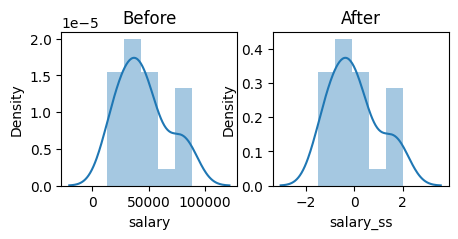

In [87]:
# checking for the nature of data
plt.figure(figsize=(5,2))
plt.subplot(1,2,1)
plt.title("Before")
sns.distplot(fe_data["salary"])
plt.subplot(1,2,2)
plt.title("After")
sns.distplot(fe_data['salary_ss'])
plt.show()

## Replace and change Data types

In [88]:
print(fe_data.info())
fe_data['age'] = fe_data["age"].astype("object")
print(fe_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        30 non-null     int64  
 1   salary     30 non-null     int64  
 2   salary_ss  30 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 852.0 bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        30 non-null     object 
 1   salary     30 non-null     int64  
 2   salary_ss  30 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes
None


## function transformer

C:\Users\ECS\AppData\Local\Temp\ipykernel_2204\2616255670.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fe_data["age"])


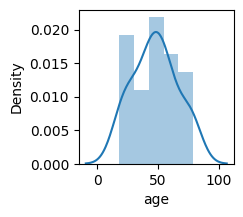

In [89]:
plt.figure(figsize = (2,2))
sns.distplot(fe_data["age"])
plt.show()

In [90]:
# converting non normal data to normal data

# changing datatype of the age column
fe_data["age"] = fe_data["age"].astype("int64")

from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer()

ft.fit(fe_data[["age"]])
fe_data["age_trans"] = ft.transform(fe_data[["age"]])
fe_data.head()

,age,salary,salary_ss,age_trans
0,47,24834,-0.930214,47
1,44,28461,-0.761475,44
2,55,81871,1.723329,55
3,57,35121,-0.451630,57
4,44,49281,0.207138,44


## train_test_split

In [114]:
hr_data = pd.read_csv("datasets/hr_data.csv")
hr_data.drop(columns = ["emp_id", "department"], inplace = True)
hr_data.head()

,age,experience,salary
0,35.0,6.0,67250.0
1,27.0,0.0,52750.0
2,27.0,0.0,52750.0
3,21.0,3.0,59500.0
4,33.0,13.0,84250.0


In [115]:
# Null values
hr_data.dropna(inplace=True)
hr_data.isnull().sum()

age           0
experience    0
salary        0
dtype: int64

In [98]:
x = loan_data.iloc[:,:-1]
y = loan_data["status_encode"]
from sklearn.model_selection import train_test_split
x_train, y_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size = 0.2)

In [118]:
x = hr_data.iloc[:,-1]
y = hr_data["salary"]

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [99]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [101]:
# Apply Sequential Feature Selector
sfs = sfs(
    lr,
    n_features_to_select=2,   # Number of features to select
    direction='forward',      # Use forward selection
    scoring='accuracy',       # Metric to evaluate
    cv=5                      # Number of cross-validation folds
)

In [102]:
sfs.fit(x_train, y_train)
# Get selected features
selected_features = sfs.get_support()

print("Selected features:", x_train.columns[selected_features])

ValueError: could not convert string to float: 'LP002205'